# Load Data

In [21]:
from pathlib import Path

test_normal_imgs = Path("test/NORMAL")
test_pneumonia_imgs = Path("test/PNEUMONIA")

train_normal_imgs = Path("train/NORMAL")
train_pneumonia_imgs = Path("train/PNEUMONIA")

val_normal_imgs = Path("val/NORMAL")
val_pneumonia_imgs = Path("val/PNEUMONIA")

# Data Visualisation
## Distribution


/Users/nicolasdambreville/Dev/Epitech/T-DEV-810/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


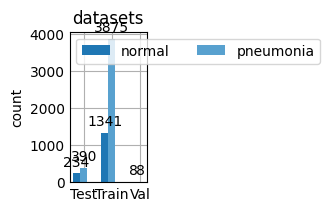

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List

datasets = ("Test", "Train", "Val")

test_normal_paths = [img for img in test_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
test_pneumonia_paths = [img for img in test_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
train_normal_paths = [img for img in train_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
train_pneumonia_paths = [img for img in train_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
val_normal_paths = [img for img in val_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
val_pneumonia_paths = [img for img in val_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]

def display_distribution(list_test_normal_imgs : List[Path], list_test_pneumonia_imgs : List[Path], list_train_normal_imgs : List[Path], list_train_pneumonia_imgs : List[Path], list_val_normal_imgs : List[Path], list_val_pneumonia_imgs : List[Path]):
    groups = {
        'normal': (len(list_test_normal_imgs), len(list_train_normal_imgs), len(list_val_normal_imgs)),
        'pneumonia': (len(list_test_pneumonia_imgs), len(list_train_pneumonia_imgs), len(list_val_pneumonia_imgs)),
    }


    x = np.arange(len(datasets))  
    width = 0.25 
    multiplier = 0

    _, ax = plt.subplots(layout='constrained')

    for attribute, measurement in groups.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        multiplier += 1

    ax.set_ylabel('count')
    ax.set_title('datasets')
    ax.set_xticks(x + width, datasets)
    ax.legend(loc='upper left', ncols=3)

    plt.show()

display_distribution(test_normal_paths, test_pneumonia_paths, train_normal_paths, train_pneumonia_paths, val_normal_paths, val_pneumonia_paths)

# Dataset
## fix distribution

/Users/nicolasdambreville/Dev/Epitech/T-DEV-810/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


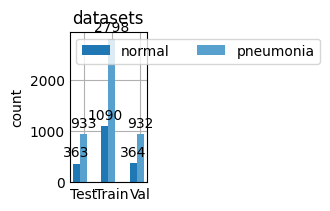

In [30]:
from sklearn.model_selection import train_test_split

all_paths = train_normal_paths + train_pneumonia_paths
all_labels = [0] * len(train_normal_paths) + [1] * len(train_pneumonia_paths)

train_paths, val_paths, y_train, y_val = train_test_split(
    all_paths,
    all_labels,
    test_size=0.4,
    random_state=42,
    stratify=all_labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    val_paths,
    y_val,
    test_size=0.5,
    random_state=42,
    stratify=y_val
)



display_distribution([test_path for test_path in test_paths if test_path.parent.name == "NORMAL"], [test_path for test_path in test_paths if test_path.parent.name == "PNEUMONIA"], [train_path for train_path in train_paths if train_path.parent.name == "NORMAL"], [train_path for train_path in train_paths if train_path.parent.name == "PNEUMONIA"], [val_path for val_path in val_paths if val_path.parent.name == "NORMAL"], [val_path for val_path in val_paths if val_path.parent.name == "PNEUMONIA"])


## Normalize image pixel 

Text(0.5, 1.0, 'Scatter Plot of Image Dimensions')

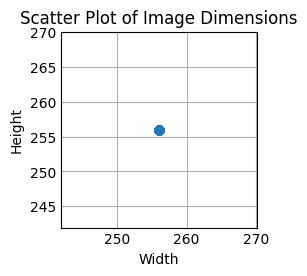

In [34]:
from PIL import Image
from typing import List

# TODO : télécharger à nouveau le dataset avant le changement de taille 

img_width:List[int]=[]
img_height:List[int]=[]
for img_lists in [ train_paths, val_paths, test_paths]:
    for img_path in img_lists: 
        assert  isinstance(img_path,Path)   
        img = Image.open(img_path)
        width, height = img.size
        img_width.append(width)
        img_height.append(height)

plt.scatter(img_width, img_height)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Scatter Plot of Image Dimensions')

In [35]:


TARGET_SIZE = (256,256)

def paths_to_matrix(list_imgs : List[Path]) -> np.ndarray:
    images = []
    for img_path in list_imgs: 
        assert  isinstance(img_path,Path)   
        img = Image.open(img_path).convert("L")
        img = img.resize(TARGET_SIZE)
        img_array = np.array(img)
        img_flat = img_array.flatten()
        images.append(img_flat)

    return np.array(images)


train_imgs=paths_to_matrix(train_paths)
val_imgs=paths_to_matrix(val_paths)
test_imgs=paths_to_matrix(test_paths)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=2000)

model.fit(train_imgs, y_train)

y_pred = model.predict(test_imgs)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9382716049382716


# ajouter les infos sur le résultat (ROC, perte etc)
# ajouter un tableau avec le résultat et les étape de prépapration de dataset + entrainemnt
# point à ajuster normaliser le bit de nuance de gris entre 0 et 1 
# essayer en rgb plutôt qu'en nuance de gris 
# augmenter ou diminuer la résolution d'image 
# augmenter la taille du dataset d'entrainement 
# a quoi sert le val dataset 
# tester d'autre modèle 
# tester avec une meilleur répartition malade _ non malade 